In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
from analysis_tools.workflows.evaluation_flow import evaluation_flow
from analysis_tools.workflows.BDT_pipeline import run_bdt_pipeline
from analysis_tools.namings.BDT_feature_naming import BDT_feature_name_change
from analysis_tools.BDT_tools.Testset_preparation import create_learning_input,annotate_labels
from analysis_tools.BDT_tools.BDT_evaluation import find_best_two_bdt_thresholds,plot_bdt_threshold_scan
from analysis_tools.workflows.prediction_flow import prediction_flow,predict_scores
from analysis_tools.my_selectors.apply_selection import apply_selection


/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [3]:
model_configs = [
  {
    'name':'bdt1',
    'sig_mask': lambda df: 
                   (df['sig_bdt1']) & 
                   (df['TrueLength'] > 10),
    'bg_mask' : 'bg_bdt1'  
  },
  {
    'name':'bdt2',
    'sig_mask': lambda df: 
                   (df['sig_bdt1']) & 
                   (df['TrueLength'] > 10),
    'bg_mask' :'bg_bdt2'
  }
]

In [4]:
features_list = [
'TauMonoDiff_rlogl',
'Taupede_Asymmetry',
'Taupede_Distance',
'Taupede1_Particles_energy',
'Taupede2_Particles_energy',
'cscdSBU_MonopodFit4_noDC_zenith',
'MonopodFit_iMIGRAD_PPB0_Delay_ice',
'CVStatistics_q_max_doms',
'cscdSBU_VertexRecoDist_CscdLLh',
'MonopodFit_iMIGRAD_PPB0_energy',
'cscdSBU_Qtot_HLC_log',
'Taupede_ftpFitParams_rlogl',
'cscdSBU_MonopodFit4_noDCFitParams_rlogl',
]

In [23]:
df_train = pd.read_parquet("/data/user/tvaneede/GlobalFit/reco_processing/NNMFit/datasets/bdt/SnowStorm_v2_HESE_Baseline_v5_noMuon/dataset_IC86_pass2_SnowStorm_v2_FTP_v5_noMuon.parquet")
df_test = df_train.copy()

In [24]:
Taupede_name = 'Taupede'
precut_dict = {
    'MonopodFit_iMIGRAD_PPB0_energy':('>', 10**4.5),
                  'cscdSBU_Qtot_HLC_log':('>', 3),
                  f'{Taupede_name}_Distance':[('>', 10),('<', 400)],
                #   'cscdSBU_LE_bdt_input_cscdSBU_I3XYScale_noDC_value':('<', 0.9),
                #   'cscdSBU_MonopodFit4_noDC_z':{'and':[('>', -500),('<', 500)],
                #                                 'or':[('>', -50), ('<', -150)]},
                #   f'{Taupede_name}_1Particles_x':[('>', -500),('<', 500)],
                #   f'{Taupede_name}_1Particles_y':[('>', -500),('<', 500)],
                #   f'{Taupede_name}_1Particles_z':{'and':[('>', -500),('<', 500)],
                #                                   'or':[('>', -50), ('<', -150)]},
                #   f'{Taupede_name}_2Particles_x':[('>', -500),('<', 500)],
                #   f'{Taupede_name}_2Particles_y':[('>', -500),('<', 500)],
                #   f'{Taupede_name}_2Particles_z':{'and':[('>', -500),('<', 500)],
                #                                   'or':[('>', -50), ('<', -150)]},
}

df_train_precut = apply_selection(df_train,precut_dict).copy()
df_test_precut = apply_selection(df_test,precut_dict).copy()

# Training

['TauMonoDiff_rlogl', 'Taupede_Asymmetry', 'Taupede_Distance', 'Taupede1_Particles_energy', 'Taupede2_Particles_energy', 'cscdSBU_MonopodFit4_noDC_zenith', 'MonopodFit_iMIGRAD_PPB0_Delay_ice', 'CVStatistics_q_max_doms', 'cscdSBU_VertexRecoDist_CscdLLh', 'MonopodFit_iMIGRAD_PPB0_energy', 'cscdSBU_Qtot_HLC_log', 'Taupede_ftpFitParams_rlogl', 'cscdSBU_MonopodFit4_noDCFitParams_rlogl']
Index(['event_id', 'mjd', 'reco_energy', 'reco_energy_exists',
       'reco_energy_fit_status', 'reco_dir_fit_status', 'reco_dir',
       'reco_dir_exists', 'reco_length', 'reco_length_exists',
       ...
       'is_nue', 'is_numu', 'is_nutau', 'is_numuCC', 'is_numuNC', 'sig_bdt1',
       'bg_bdt1', 'sig_bdt2', 'bg_bdt2', 'label'],
      dtype='object', length=121)
Fitting 5 folds for each of 96 candidates, totalling 480 fits


/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of X

Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output/bdt1_model.pkl
Trained bdt1, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output/bdt1_model.pkl


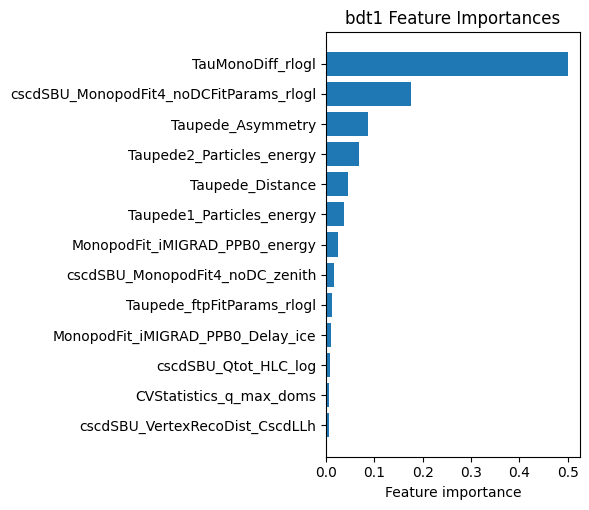

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output/bdt1_importances.png
['TauMonoDiff_rlogl', 'Taupede_Asymmetry', 'Taupede_Distance', 'Taupede1_Particles_energy', 'Taupede2_Particles_energy', 'cscdSBU_MonopodFit4_noDC_zenith', 'MonopodFit_iMIGRAD_PPB0_Delay_ice', 'CVStatistics_q_max_doms', 'cscdSBU_VertexRecoDist_CscdLLh', 'MonopodFit_iMIGRAD_PPB0_energy', 'cscdSBU_Qtot_HLC_log', 'Taupede_ftpFitParams_rlogl', 'cscdSBU_MonopodFit4_noDCFitParams_rlogl']
Index(['event_id', 'mjd', 'reco_energy', 'reco_energy_exists',
       'reco_energy_fit_status', 'reco_dir_fit_status', 'reco_dir',
       'reco_dir_exists', 'reco_length', 'reco_length_exists',
       ...
       'is_nue', 'is_numu', 'is_nutau', 'is_numuCC', 'is_numuNC', 'sig_bdt1',
       'bg_bdt1', 'sig_bdt2', 'bg_bdt2', 'label'],
      dtype='object', length=121)
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to /data/user/tvaneede/GlobalFit/reco_proce

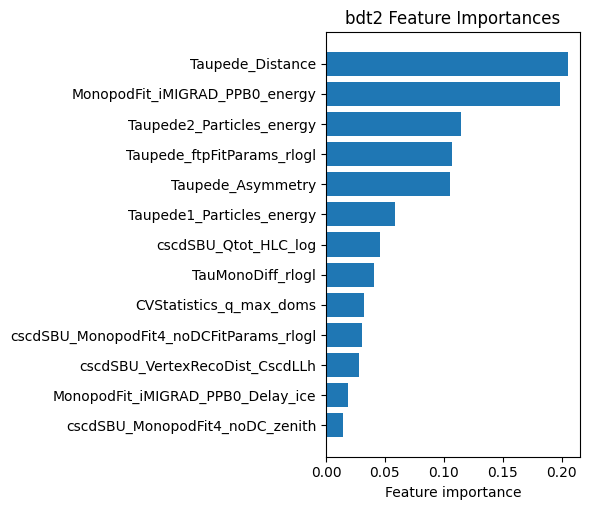

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output/bdt2_importances.png

=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 42671
[powerlaw] rate        = 9.39251e-08
[powerlaw] uncertainty = 2.25407e-09
Calculating rates for flavor: numu
Raw event count: 57283
[powerlaw] rate        = 9.14179e-08
[powerlaw] uncertainty = 6.24741e-10
Calculating rates for flavor: nutau
Raw event count: 67583
[powerlaw] rate        = 1.00973e-07
[powerlaw] uncertainty = 7.45352e-10


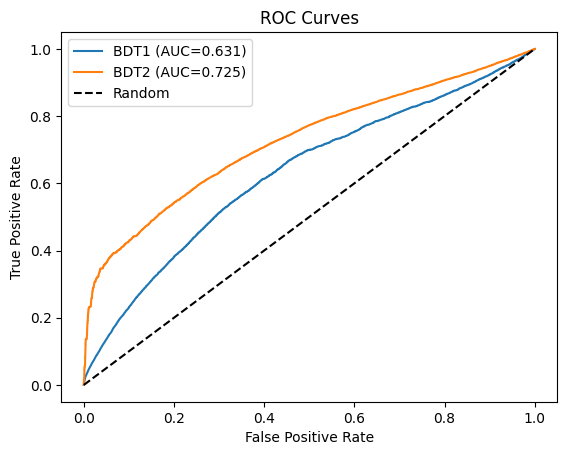

saving roc curves


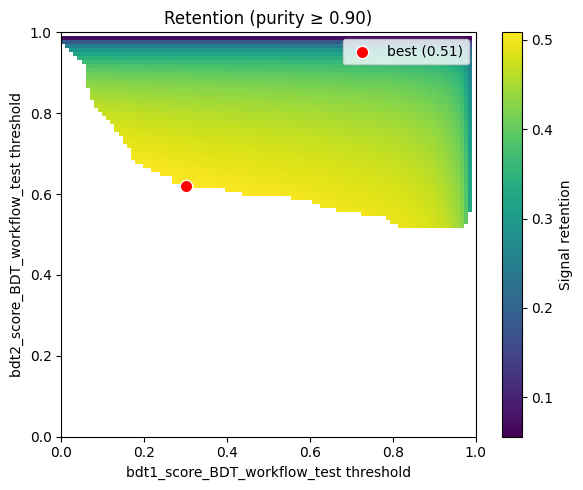


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 519
[powerlaw] rate        = 2.08674e-09
[powerlaw] uncertainty = 4.8159e-10
Calculating post-BDT rates for flavor: numu
Raw event count: 3066
[powerlaw] rate        = 3.50598e-09
[powerlaw] uncertainty = 1.09855e-10
Calculating post-BDT rates for flavor: nutau
Raw event count: 38231
[powerlaw] rate        = 5.13236e-08
[powerlaw] uncertainty = 5.00965e-10


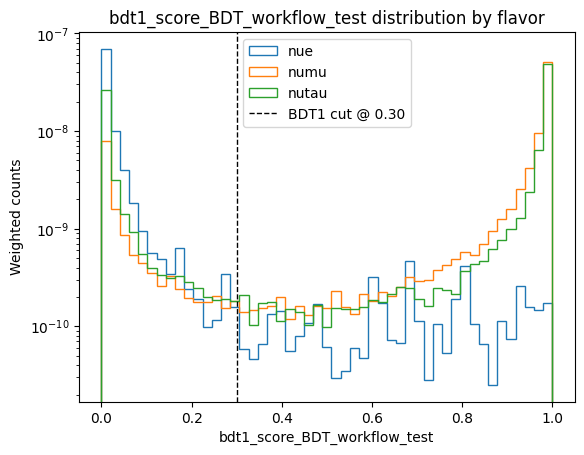

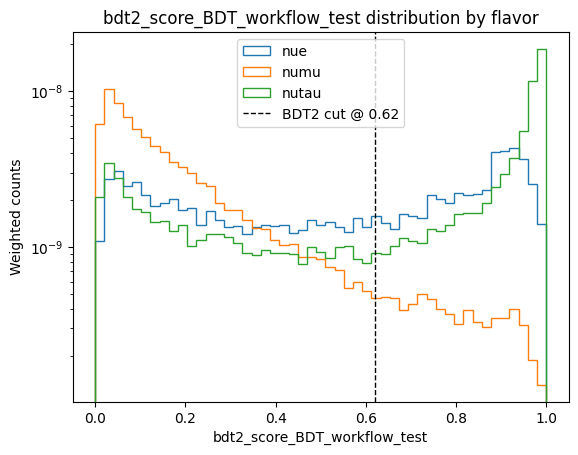

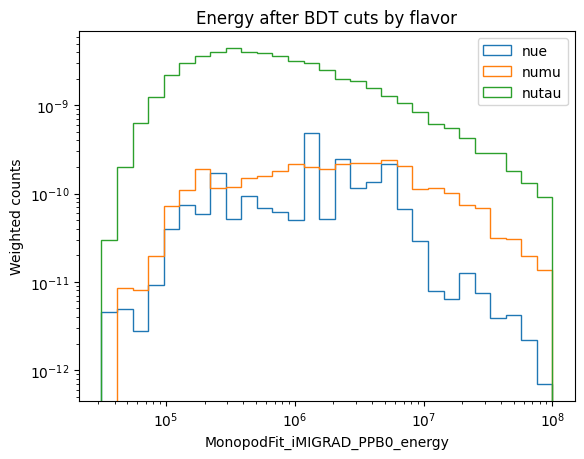


Final purity: 0.902, efficiency: 0.508


In [27]:
model_name = 'BDT_workflow_test'

models, summary = run_bdt_pipeline(
    df_train_precut, df_train_precut,
    global_precuts = None,
    model_configs  = model_configs,
    features       = features_list,
    weight_col     = 'powerlaw',
    purity_target  = 0.90,
    score_cols     = [f'bdt1_score_{model_name}',f'bdt2_score_{model_name}'],
    train_outdir   = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output/',
    eval_outdir    = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/eval_output/'
) 

Lets first reweight to the HESE spectrum

In [28]:
per_flavor_norm = 2.12
gamma_astro = 2.87
norm_factor = 0.5 * per_flavor_norm * 1e-18
for df in (df_train_precut, df_test_precut):
    e = df["MCPrimaryEnergy"] / 1e5
    df["fluxless_weight"] = df["powerlaw"] * 1e18 * e**2
    df["weight"] = df["fluxless_weight"] * norm_factor * e**(-gamma_astro)

['TauMonoDiff_rlogl', 'Taupede_Asymmetry', 'Taupede_Distance', 'Taupede1_Particles_energy', 'Taupede2_Particles_energy', 'cscdSBU_MonopodFit4_noDC_zenith', 'MonopodFit_iMIGRAD_PPB0_Delay_ice', 'CVStatistics_q_max_doms', 'cscdSBU_VertexRecoDist_CscdLLh', 'MonopodFit_iMIGRAD_PPB0_energy', 'cscdSBU_Qtot_HLC_log', 'Taupede_ftpFitParams_rlogl', 'cscdSBU_MonopodFit4_noDCFitParams_rlogl']
Index(['event_id', 'mjd', 'reco_energy', 'reco_energy_exists',
       'reco_energy_fit_status', 'reco_dir_fit_status', 'reco_dir',
       'reco_dir_exists', 'reco_length', 'reco_length_exists',
       ...
       'is_nue', 'is_numu', 'is_nutau', 'is_numuCC', 'is_numuNC', 'sig_bdt1',
       'bg_bdt1', 'sig_bdt2', 'bg_bdt2', 'label'],
      dtype='object', length=123)
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_hese_weight/bdt1_model.pkl
Trained bdt1, saved to /data/user/tvaneede/GlobalFit/reco_proce

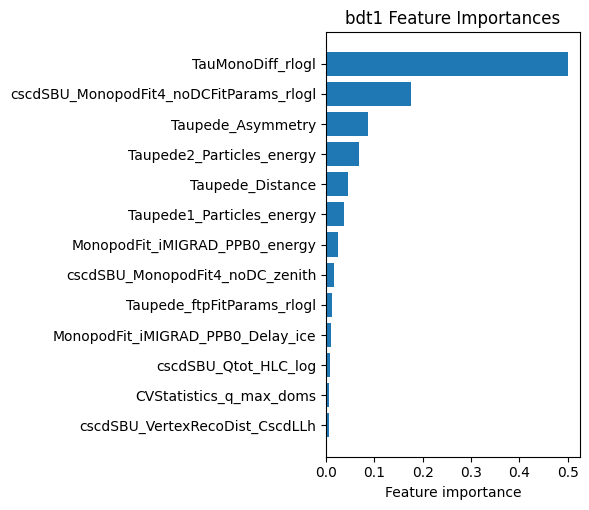

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_hese_weight/bdt1_importances.png
['TauMonoDiff_rlogl', 'Taupede_Asymmetry', 'Taupede_Distance', 'Taupede1_Particles_energy', 'Taupede2_Particles_energy', 'cscdSBU_MonopodFit4_noDC_zenith', 'MonopodFit_iMIGRAD_PPB0_Delay_ice', 'CVStatistics_q_max_doms', 'cscdSBU_VertexRecoDist_CscdLLh', 'MonopodFit_iMIGRAD_PPB0_energy', 'cscdSBU_Qtot_HLC_log', 'Taupede_ftpFitParams_rlogl', 'cscdSBU_MonopodFit4_noDCFitParams_rlogl']
Index(['event_id', 'mjd', 'reco_energy', 'reco_energy_exists',
       'reco_energy_fit_status', 'reco_dir_fit_status', 'reco_dir',
       'reco_dir_exists', 'reco_length', 'reco_length_exists',
       ...
       'is_nue', 'is_numu', 'is_nutau', 'is_numuCC', 'is_numuNC', 'sig_bdt1',
       'bg_bdt1', 'sig_bdt2', 'bg_bdt2', 'label'],
      dtype='object', length=123)
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to /data/user/tvaneede/GlobalFi

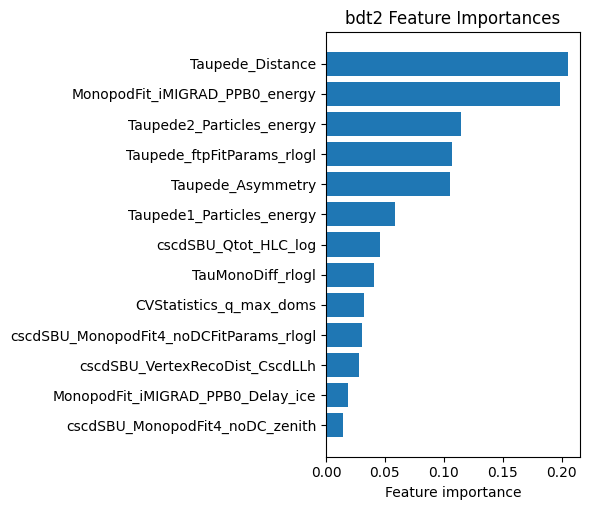

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_hese_weight/bdt2_importances.png

=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 42671
[weight] rate        = 5.53997e-08
[weight] uncertainty = 6.13155e-10
Calculating rates for flavor: numu
Raw event count: 57283
[weight] rate        = 3.25764e-08
[weight] uncertainty = 3.05579e-10
Calculating rates for flavor: nutau
Raw event count: 67583
[weight] rate        = 3.71937e-08
[weight] uncertainty = 4.40607e-10


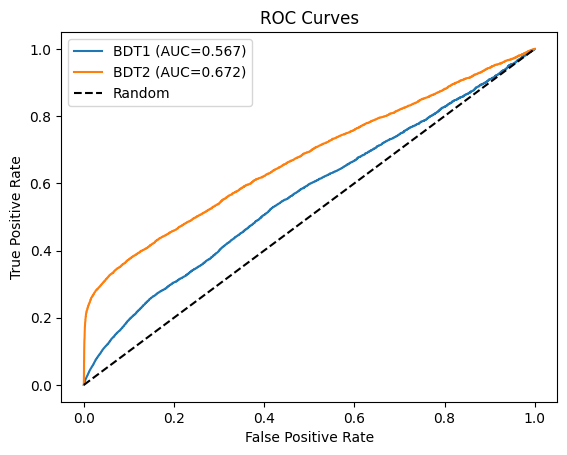

saving roc curves


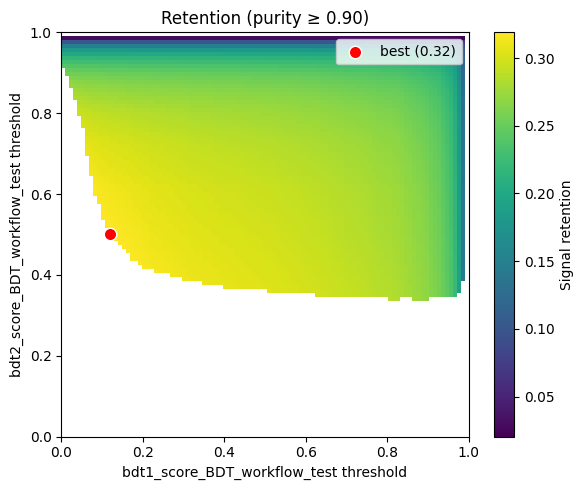


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 1460
[weight] rate        = 6.70269e-10
[weight] uncertainty = 4.33755e-11
Calculating post-BDT rates for flavor: numu
Raw event count: 5544
[weight] rate        = 6.37237e-10
[weight] uncertainty = 2.62572e-11
Calculating post-BDT rates for flavor: nutau
Raw event count: 42076
[weight] rate        = 1.18675e-08
[weight] uncertainty = 1.78453e-10


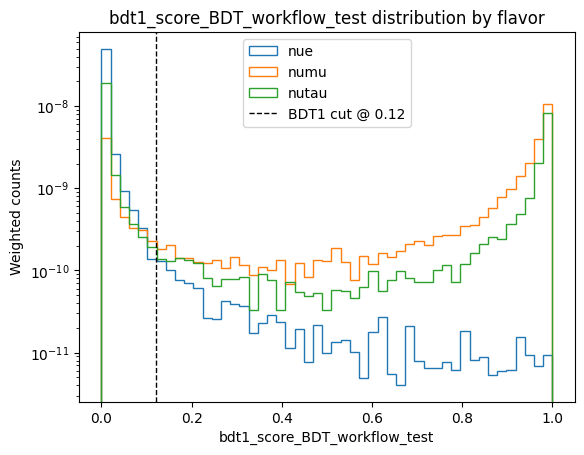

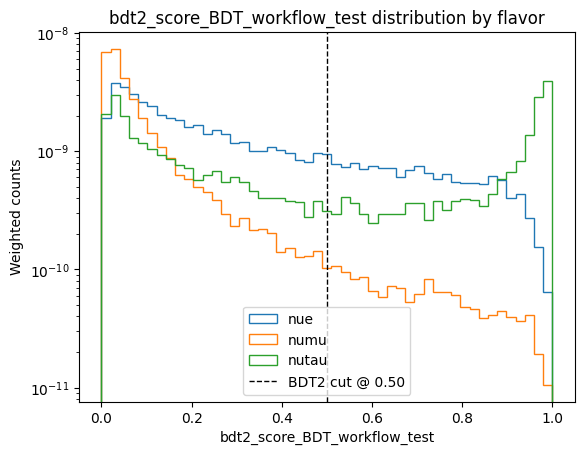

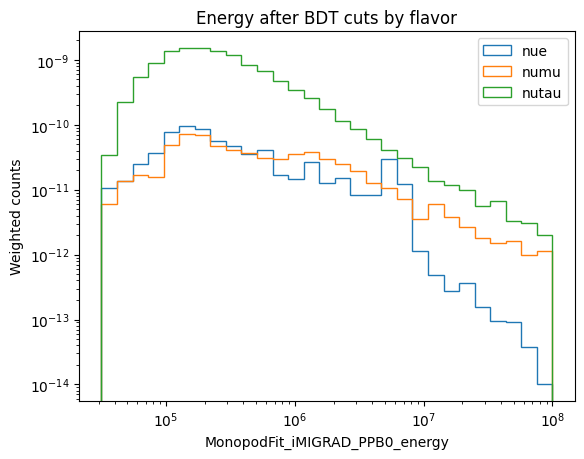


Final purity: 0.901, efficiency: 0.319


In [30]:
model_name = 'BDT_workflow_test'

models, summary = run_bdt_pipeline(
    df_train_precut, df_train_precut,
    global_precuts = None,
    model_configs  = model_configs,
    features       = features_list,
    weight_col     = 'weight',
    purity_target  = 0.90,
    score_cols     = [f'bdt1_score_{model_name}',f'bdt2_score_{model_name}'],
    train_outdir   = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_hese_weight/',
    eval_outdir    = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/eval_output_hese_weight/'
) 

Lets remove the precuts as a benchmark

In [34]:
precut_dict = {}

df_train_precut = apply_selection(df_train,precut_dict).copy()
df_test_precut = apply_selection(df_test,precut_dict).copy()

per_flavor_norm = 2.12
gamma_astro = 2.87
norm_factor = 0.5 * per_flavor_norm * 1e-18
for df in (df_train_precut, df_test_precut):
    e = df["MCPrimaryEnergy"] / 1e5
    df["fluxless_weight"] = df["powerlaw"] * 1e18 * e**2
    df["weight"] = df["fluxless_weight"] * norm_factor * e**(-gamma_astro)

['TauMonoDiff_rlogl', 'Taupede_Asymmetry', 'Taupede_Distance', 'Taupede1_Particles_energy', 'Taupede2_Particles_energy', 'cscdSBU_MonopodFit4_noDC_zenith', 'MonopodFit_iMIGRAD_PPB0_Delay_ice', 'CVStatistics_q_max_doms', 'cscdSBU_VertexRecoDist_CscdLLh', 'MonopodFit_iMIGRAD_PPB0_energy', 'cscdSBU_Qtot_HLC_log', 'Taupede_ftpFitParams_rlogl', 'cscdSBU_MonopodFit4_noDCFitParams_rlogl']
Index(['event_id', 'mjd', 'reco_energy', 'reco_energy_exists',
       'reco_energy_fit_status', 'reco_dir_fit_status', 'reco_dir',
       'reco_dir_exists', 'reco_length', 'reco_length_exists',
       ...
       'is_nue', 'is_numu', 'is_nutau', 'is_numuCC', 'is_numuNC', 'sig_bdt1',
       'bg_bdt1', 'sig_bdt2', 'bg_bdt2', 'label'],
      dtype='object', length=123)
Fitting 5 folds for each of 96 candidates, totalling 480 fits


/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of X

Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_noprecuts/bdt1_model.pkl
Trained bdt1, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_noprecuts/bdt1_model.pkl


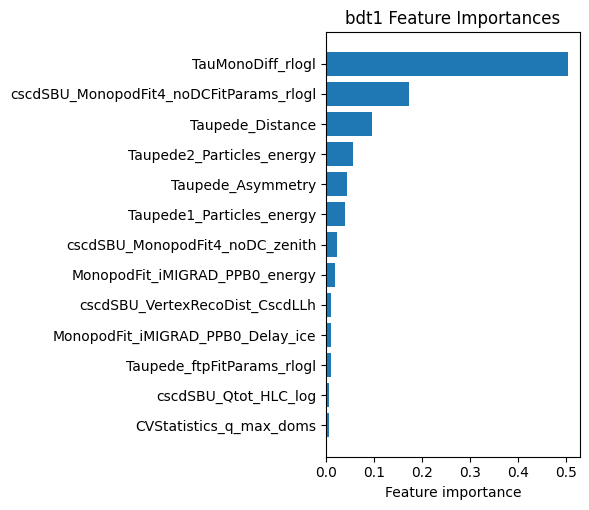

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_noprecuts/bdt1_importances.png
['TauMonoDiff_rlogl', 'Taupede_Asymmetry', 'Taupede_Distance', 'Taupede1_Particles_energy', 'Taupede2_Particles_energy', 'cscdSBU_MonopodFit4_noDC_zenith', 'MonopodFit_iMIGRAD_PPB0_Delay_ice', 'CVStatistics_q_max_doms', 'cscdSBU_VertexRecoDist_CscdLLh', 'MonopodFit_iMIGRAD_PPB0_energy', 'cscdSBU_Qtot_HLC_log', 'Taupede_ftpFitParams_rlogl', 'cscdSBU_MonopodFit4_noDCFitParams_rlogl']
Index(['event_id', 'mjd', 'reco_energy', 'reco_energy_exists',
       'reco_energy_fit_status', 'reco_dir_fit_status', 'reco_dir',
       'reco_dir_exists', 'reco_length', 'reco_length_exists',
       ...
       'is_nue', 'is_numu', 'is_nutau', 'is_numuCC', 'is_numuNC', 'sig_bdt1',
       'bg_bdt1', 'sig_bdt2', 'bg_bdt2', 'label'],
      dtype='object', length=123)
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to /data/user/tvaneede/GlobalFit/

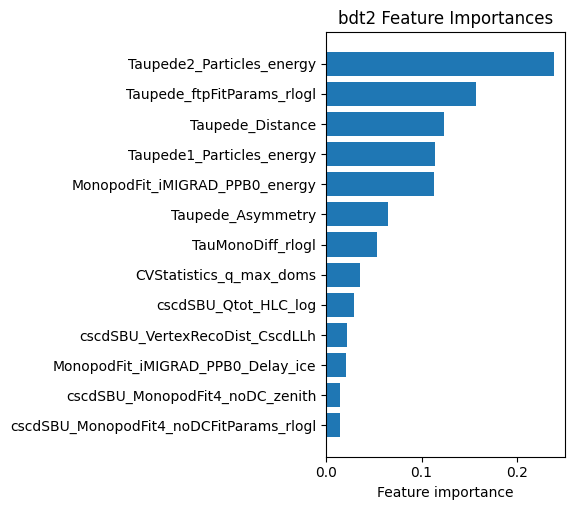

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_noprecuts/bdt2_importances.png

=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 139318
[weight] rate        = 1.53912e-07
[weight] uncertainty = 1.01145e-09
Calculating rates for flavor: numu
Raw event count: 98543
[weight] rate        = 5.5793e-08
[weight] uncertainty = 4.15194e-10
Calculating rates for flavor: nutau
Raw event count: 129107
[weight] rate        = 9.07534e-08
[weight] uncertainty = 7.26443e-10


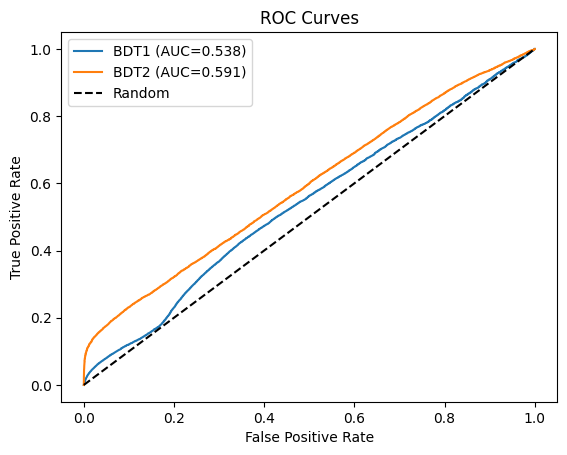

saving roc curves


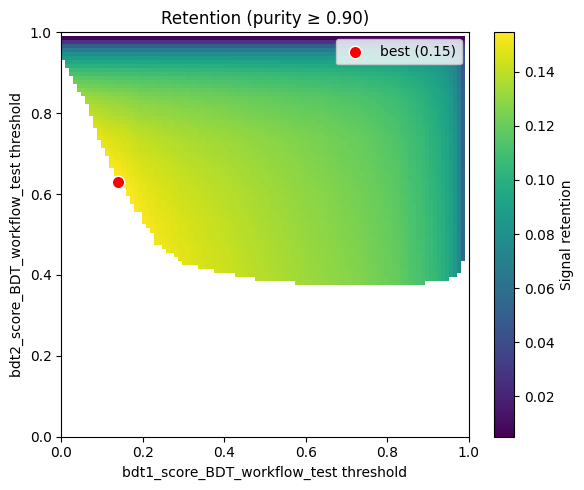


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 3555
[weight] rate        = 1.01418e-09
[weight] uncertainty = 5.39181e-11
Calculating post-BDT rates for flavor: numu
Raw event count: 5883
[weight] rate        = 5.40575e-10
[weight] uncertainty = 2.37696e-11
Calculating post-BDT rates for flavor: nutau
Raw event count: 50329
[weight] rate        = 1.4027e-08
[weight] uncertainty = 1.97558e-10


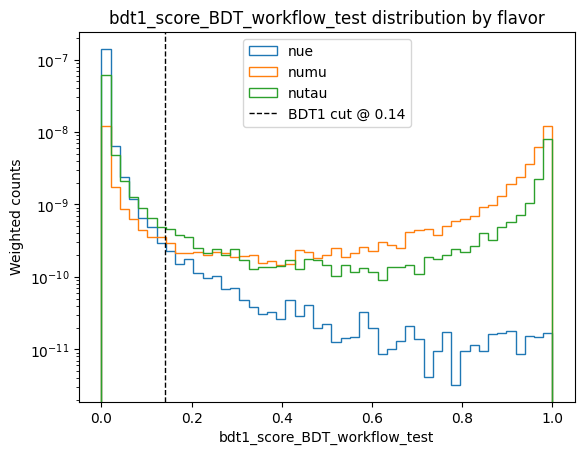

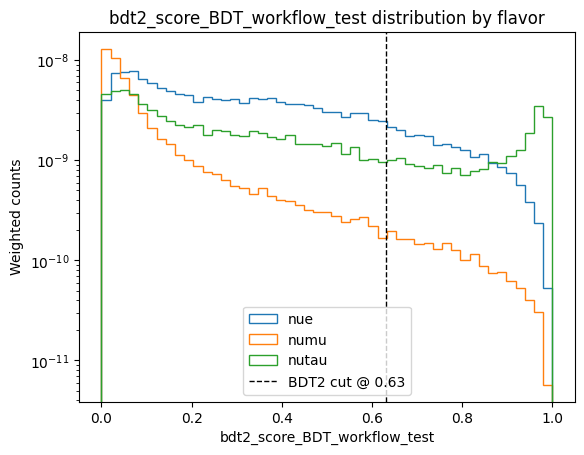

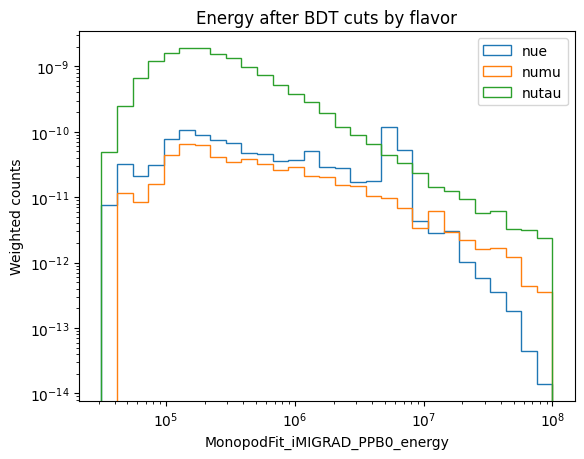


Final purity: 0.900, efficiency: 0.155


In [35]:
model_name = 'BDT_workflow_test'

models, summary = run_bdt_pipeline(
    df_train_precut, df_train_precut,
    global_precuts = None,
    model_configs  = model_configs,
    features       = features_list,
    weight_col     = 'weight',
    purity_target  = 0.90,
    score_cols     = [f'bdt1_score_{model_name}',f'bdt2_score_{model_name}'],
    train_outdir   = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_noprecuts/',
    eval_outdir    = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/eval_output_noprecuts/'
) 

Lets actually have some sensible precuts

In [36]:
Taupede_name = "TaupedeFit_iMIGRAD_PPB0"
precut_dict = {
'MonopodFit_iMIGRAD_PPB0_energy':('>', 10**4.5),
'Taupede_Distance':[('>', 10),('<', 400)],
  f'{Taupede_name}_1_x':[('>', -500),('<', 500)],
  f'{Taupede_name}_1_y':[('>', -500),('<', 500)],
  f'{Taupede_name}_1_z':{'and':[('>', -500),('<', 500)],
                                  'or':[('>', -50), ('<', -150)]},
  f'{Taupede_name}_2_x':[('>', -500),('<', 500)],
  f'{Taupede_name}_2_y':[('>', -500),('<', 500)],
  f'{Taupede_name}_2_z':{'and':[('>', -500),('<', 500)],
                                  'or':[('>', -50), ('<', -150)]},
}

df_train_precut = apply_selection(df_train,precut_dict).copy()
df_test_precut = apply_selection(df_test,precut_dict).copy()

per_flavor_norm = 2.12
gamma_astro = 2.87
norm_factor = 0.5 * per_flavor_norm * 1e-18
for df in (df_train_precut, df_test_precut):
    e = df["MCPrimaryEnergy"] / 1e5
    df["fluxless_weight"] = df["powerlaw"] * 1e18 * e**2
    df["weight"] = df["fluxless_weight"] * norm_factor * e**(-gamma_astro)

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of X

Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_precuts/bdt1_model.pkl
Trained bdt1, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_precuts/bdt1_model.pkl


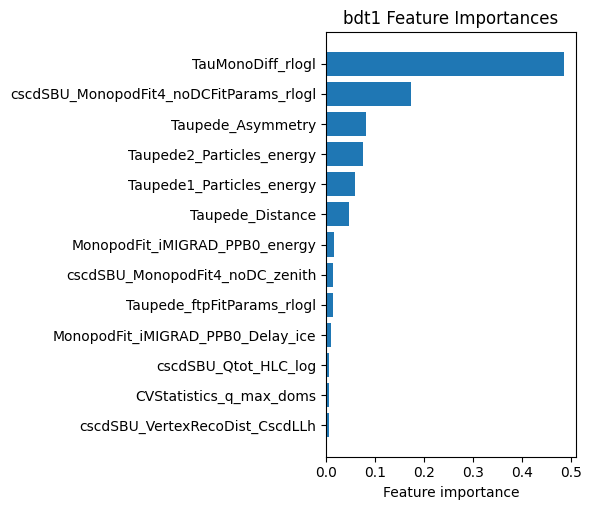

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_precuts/bdt1_importances.png
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_precuts/bdt2_model.pkl
Trained bdt2, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_precuts/bdt2_model.pkl


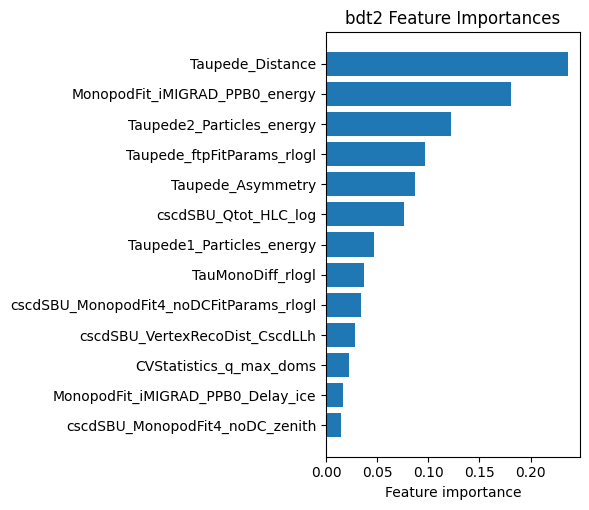

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_precuts/bdt2_importances.png

=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 34458
[weight] rate        = 4.7205e-08
[weight] uncertainty = 5.68053e-10
Calculating rates for flavor: numu
Raw event count: 42593
[weight] rate        = 2.74859e-08
[weight] uncertainty = 2.85702e-10
Calculating rates for flavor: nutau
Raw event count: 52638
[weight] rate        = 3.32846e-08
[weight] uncertainty = 4.17735e-10


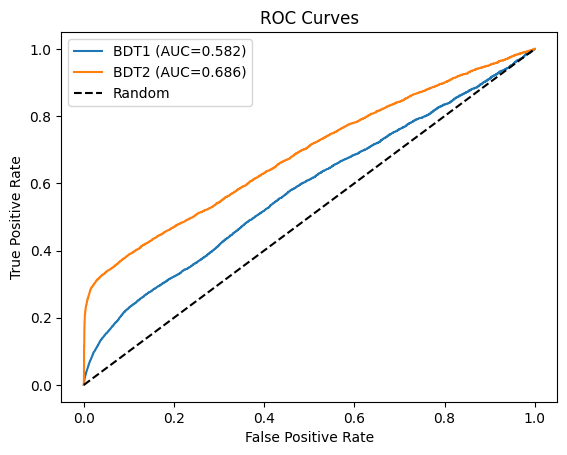

saving roc curves


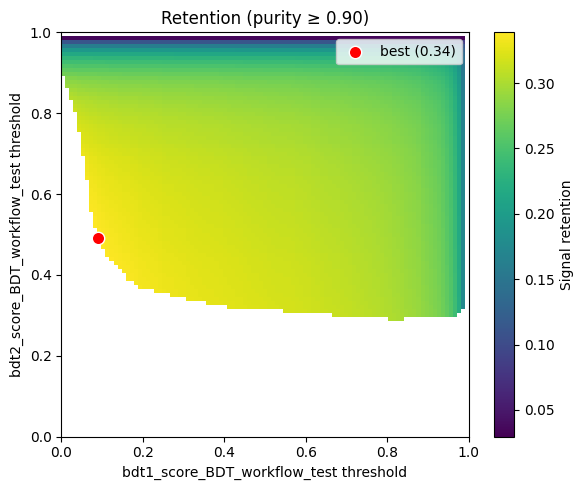


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 1327
[weight] rate        = 6.87378e-10
[weight] uncertainty = 4.18152e-11
Calculating post-BDT rates for flavor: numu
Raw event count: 3844
[weight] rate        = 5.43027e-10
[weight] uncertainty = 2.50176e-11
Calculating post-BDT rates for flavor: nutau
Raw event count: 33458
[weight] rate        = 1.12756e-08
[weight] uncertainty = 1.76014e-10


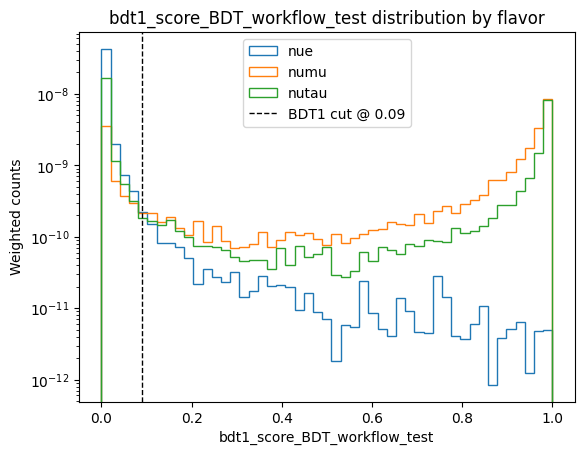

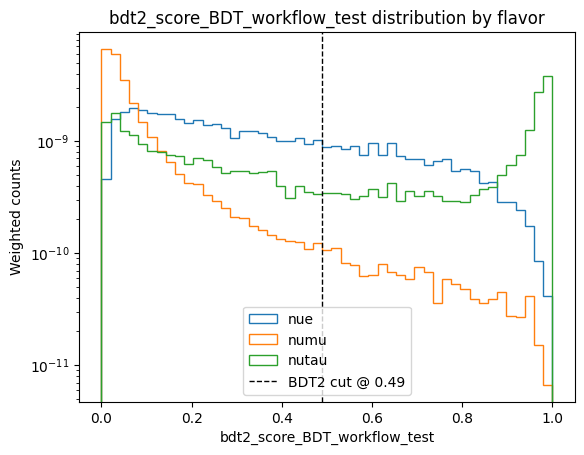

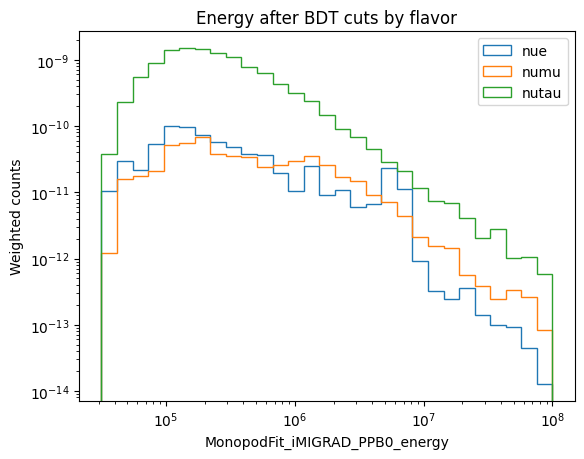


Final purity: 0.902, efficiency: 0.339


In [37]:
model_name = 'BDT_workflow_test'

models, summary = run_bdt_pipeline(
    df_train_precut, df_train_precut,
    global_precuts = None,
    model_configs  = model_configs,
    features       = features_list,
    weight_col     = 'weight',
    purity_target  = 0.90,
    score_cols     = [f'bdt1_score_{model_name}',f'bdt2_score_{model_name}'],
    train_outdir   = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_precuts/',
    eval_outdir    = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/eval_output_precuts/'
) 

Now clean up some weird/unimportant features

In [42]:
features_list = [
'TauMonoDiff_rlogl',
'Taupede_Asymmetry',
'Taupede_Distance',
'Taupede1_Particles_energy',
'Taupede2_Particles_energy',
# 'cscdSBU_MonopodFit4_noDC_zenith',
# 'MonopodFit_iMIGRAD_PPB0_Delay_ice',
# 'CVStatistics_q_max_doms',
# 'cscdSBU_VertexRecoDist_CscdLLh',
'MonopodFit_iMIGRAD_PPB0_energy',
'cscdSBU_Qtot_HLC_log',
# 'Taupede_ftpFitParams_rlogl', # bad data/mc
# 'cscdSBU_MonopodFit4_noDCFitParams_rlogl', # bad data/mc
]

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of X

Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_cleanfeatures/bdt1_model.pkl
Trained bdt1, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_cleanfeatures/bdt1_model.pkl


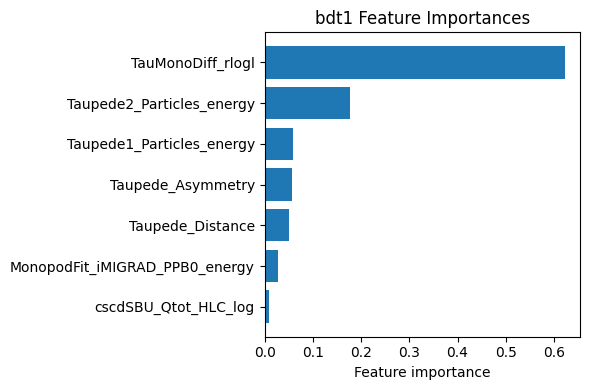

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_cleanfeatures/bdt1_importances.png
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_cleanfeatures/bdt2_model.pkl
Trained bdt2, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_cleanfeatures/bdt2_model.pkl


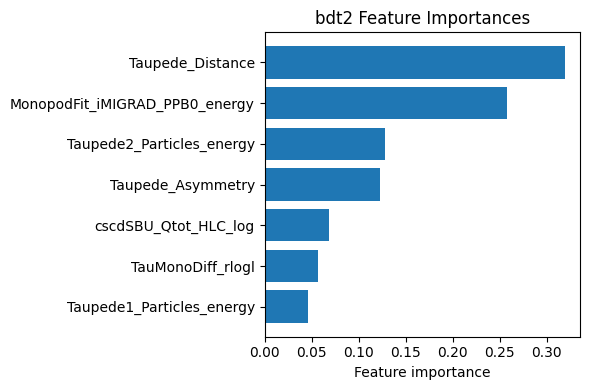

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_cleanfeatures/bdt2_importances.png

=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 34458
[weight] rate        = 4.7205e-08
[weight] uncertainty = 5.68053e-10
Calculating rates for flavor: numu
Raw event count: 42593
[weight] rate        = 2.74859e-08
[weight] uncertainty = 2.85702e-10
Calculating rates for flavor: nutau
Raw event count: 52638
[weight] rate        = 3.32846e-08
[weight] uncertainty = 4.17735e-10


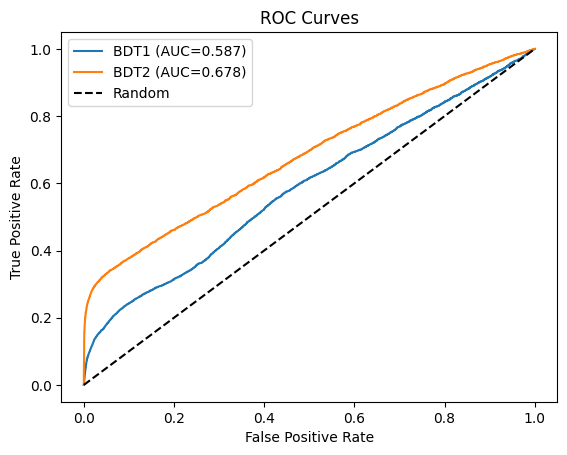

saving roc curves


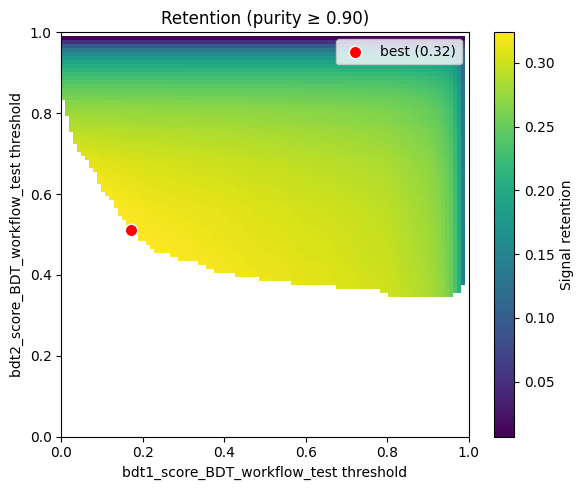


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 1018
[weight] rate        = 5.21948e-10
[weight] uncertainty = 4.43098e-11
Calculating post-BDT rates for flavor: numu
Raw event count: 4687
[weight] rate        = 6.72398e-10
[weight] uncertainty = 3.30737e-11
Calculating post-BDT rates for flavor: nutau
Raw event count: 31469
[weight] rate        = 1.07837e-08
[weight] uncertainty = 1.72042e-10


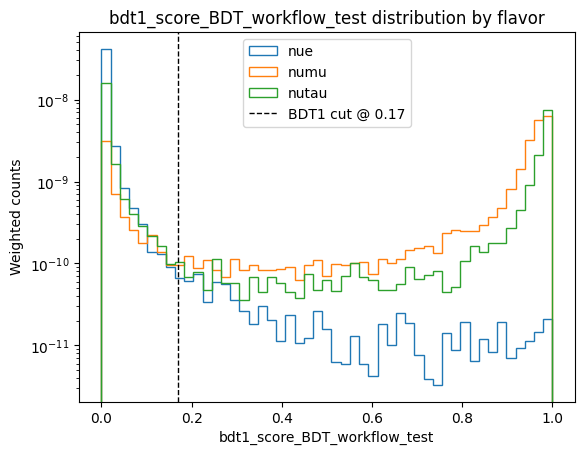

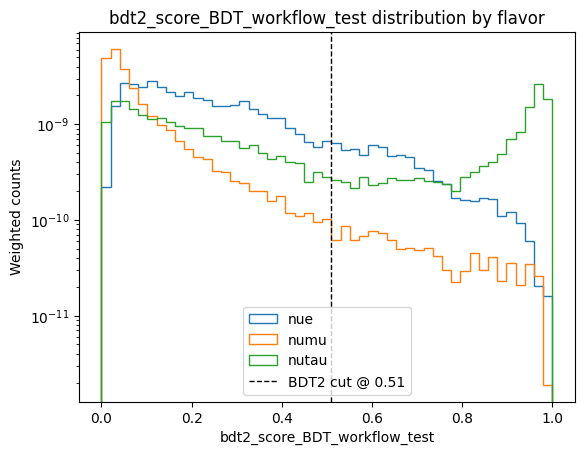

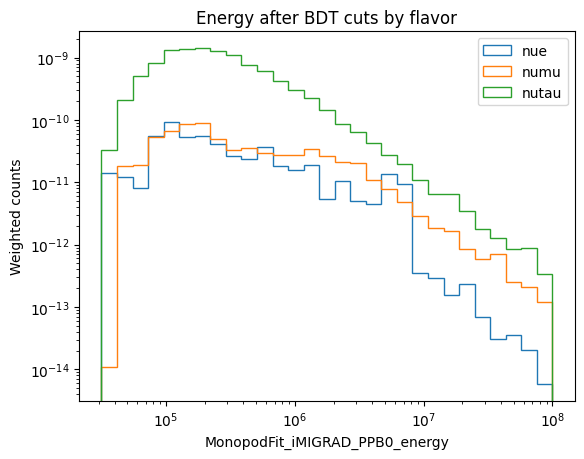


Final purity: 0.900, efficiency: 0.324


In [43]:
model_name = 'BDT_workflow_test'

models, summary = run_bdt_pipeline(
    df_train_precut, df_train_precut,
    global_precuts = None,
    model_configs  = model_configs,
    features       = features_list,
    weight_col     = 'weight',
    purity_target  = 0.90,
    score_cols     = [f'bdt1_score_{model_name}',f'bdt2_score_{model_name}'],
    train_outdir   = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_cleanfeatures/',
    eval_outdir    = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/eval_output_cleanfeatures/'
) 

We only loose a little bit of efficiency, now lets add some more features

In [44]:
features_list = [
'TauMonoDiff_rlogl',
'Taupede_Asymmetry',
'Taupede_Distance',
'Taupede1_Particles_energy',
'Taupede2_Particles_energy',
# 'cscdSBU_MonopodFit4_noDC_zenith',
# 'MonopodFit_iMIGRAD_PPB0_Delay_ice',
# 'CVStatistics_q_max_doms',
# 'cscdSBU_VertexRecoDist_CscdLLh',
'MonopodFit_iMIGRAD_PPB0_energy',
'cscdSBU_Qtot_HLC_log',
# 'Taupede_ftpFitParams_rlogl', # bad data/mc
# 'cscdSBU_MonopodFit4_noDCFitParams_rlogl', # bad data/mc

### general
'econfinement',

### event generator
'EventGeneratorDC_Thijs_length',
'RecoERatio_EventGeneratorDC_Max',

### millipede
'MonopodFit_iMIGRAD_PPB0MillipedeFitFitParams_rlogl',
'SPEFit16_PPB0MillipedeFitFitParams_rlogl',
'TaupedeFit_iMIGRAD_PPB0MillipedeFitFitParams',

'MonopodFit_iMIGRAD_PPB0MillipedeFitTruncatedDepositedEnergy',
'SPEFit16_PPB0MillipedeFitTruncatedDepositedEnergy',
'TaupedeFit_iMIGRAD_PPB0MillipedeFitTruncatedDepositedEnergy',

]

Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_manyextrafeatures/bdt1_model.pkl
Trained bdt1, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_manyextrafeatures/bdt1_model.pkl


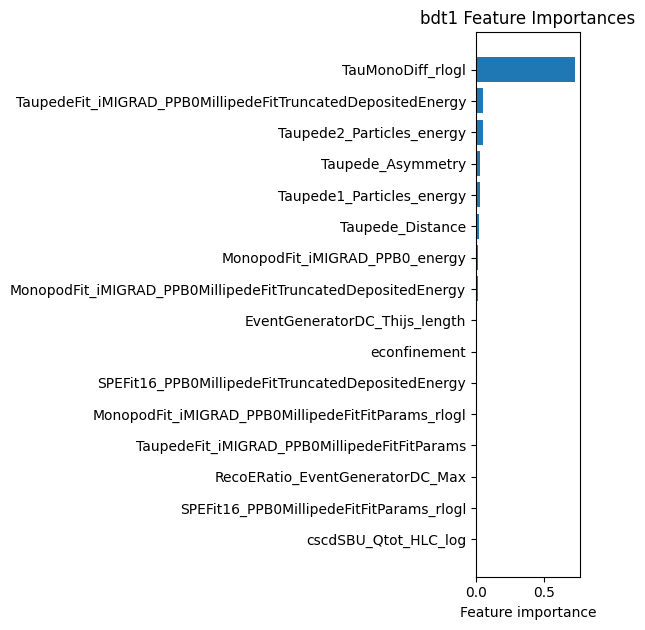

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_manyextrafeatures/bdt1_importances.png
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_manyextrafeatures/bdt2_model.pkl
Trained bdt2, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_manyextrafeatures/bdt2_model.pkl


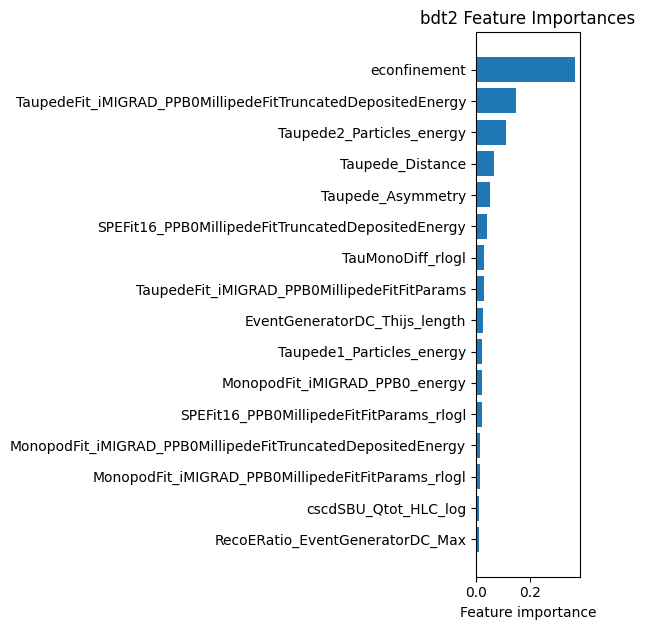

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_manyextrafeatures/bdt2_importances.png

=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 34458
[weight] rate        = 4.7205e-08
[weight] uncertainty = 5.68053e-10
Calculating rates for flavor: numu
Raw event count: 42593
[weight] rate        = 2.74859e-08
[weight] uncertainty = 2.85702e-10
Calculating rates for flavor: nutau
Raw event count: 52638
[weight] rate        = 3.32846e-08
[weight] uncertainty = 4.17735e-10


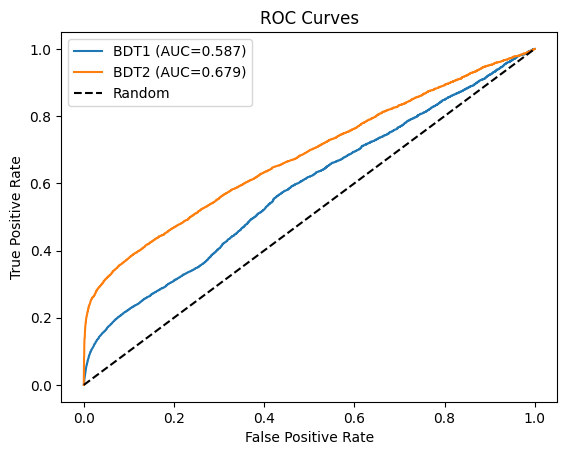

saving roc curves


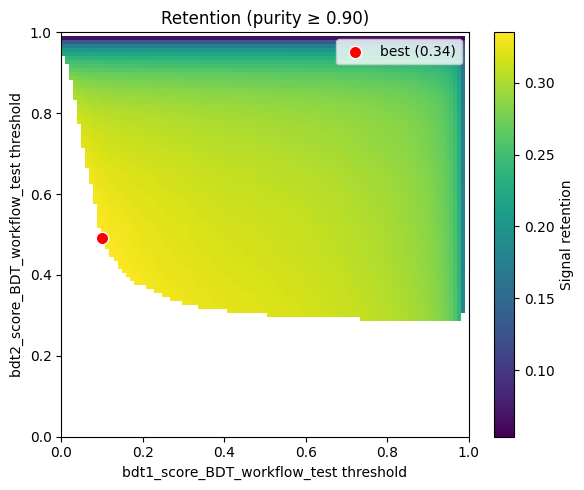


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 1388
[weight] rate        = 6.84674e-10
[weight] uncertainty = 4.69382e-11
Calculating post-BDT rates for flavor: numu
Raw event count: 3204
[weight] rate        = 5.48249e-10
[weight] uncertainty = 2.90123e-11
Calculating post-BDT rates for flavor: nutau
Raw event count: 33243
[weight] rate        = 1.11505e-08
[weight] uncertainty = 1.7512e-10


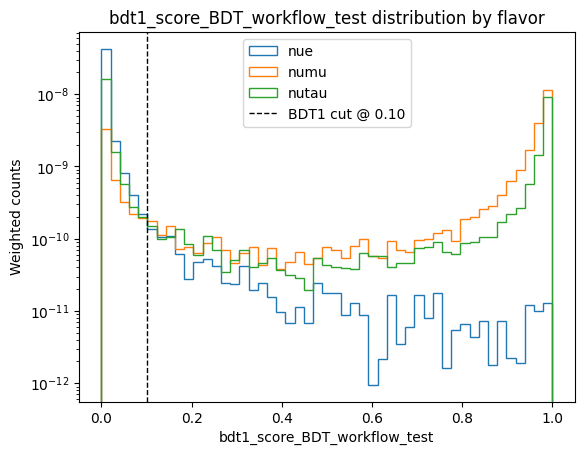

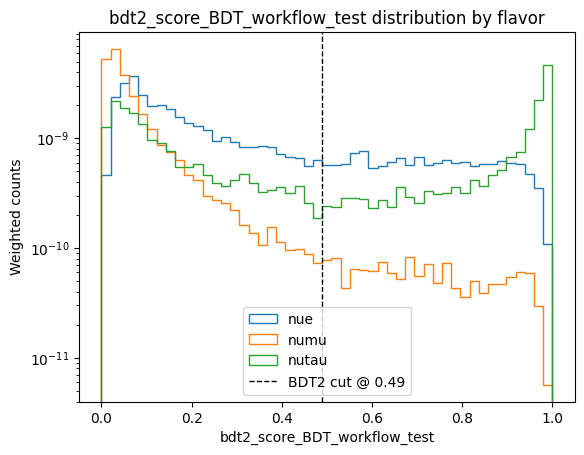

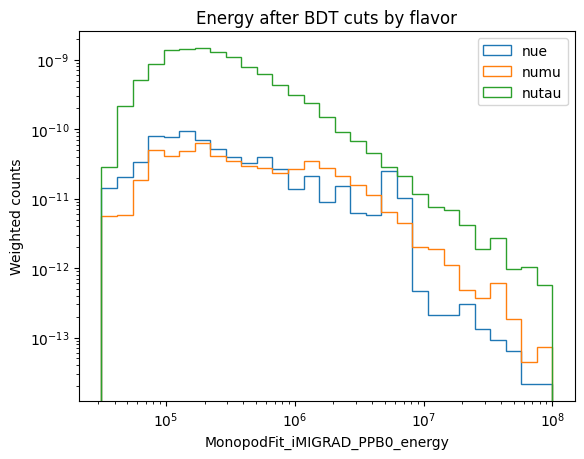


Final purity: 0.900, efficiency: 0.335


In [45]:
model_name = 'BDT_workflow_test'

models, summary = run_bdt_pipeline(
    df_train_precut, df_train_precut,
    global_precuts = None,
    model_configs  = model_configs,
    features       = features_list,
    weight_col     = 'weight',
    purity_target  = 0.90,
    score_cols     = [f'bdt1_score_{model_name}',f'bdt2_score_{model_name}'],
    train_outdir   = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_manyextrafeatures/',
    eval_outdir    = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/eval_output_manyextrafeatures/'
) 

Lets do all zheyangs features, without rlogl, and mine

In [ ]:
features_list = [
'TauMonoDiff_rlogl',
'Taupede_Asymmetry',
'Taupede_Distance',
'Taupede1_Particles_energy',
'Taupede2_Particles_energy',
'cscdSBU_MonopodFit4_noDC_zenith',
'MonopodFit_iMIGRAD_PPB0_Delay_ice',
'CVStatistics_q_max_doms',
'cscdSBU_VertexRecoDist_CscdLLh',
'MonopodFit_iMIGRAD_PPB0_energy',
'cscdSBU_Qtot_HLC_log',
# 'Taupede_ftpFitParams_rlogl', # bad data/mc
# 'cscdSBU_MonopodFit4_noDCFitParams_rlogl', # bad data/mc

### general
'econfinement',

### event generator
'EventGeneratorDC_Thijs_length',
'RecoERatio_EventGeneratorDC_Max',

### millipede
'MonopodFit_iMIGRAD_PPB0MillipedeFitFitParams_rlogl',
'SPEFit16_PPB0MillipedeFitFitParams_rlogl',
'TaupedeFit_iMIGRAD_PPB0MillipedeFitFitParams_rlogl',

'MonopodFit_iMIGRAD_PPB0MillipedeFitTruncatedDepositedEnergy',
'SPEFit16_PPB0MillipedeFitTruncatedDepositedEnergy',
'TaupedeFit_iMIGRAD_PPB0MillipedeFitTruncatedDepositedEnergy',

]

Fitting 5 folds for each of 96 candidates, totalling 480 fits


/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(
/data/user/tvaneede/software/py_venvs/py3-v4.4.1_reco-v1.1.0/lib/python3.12/site-packages/xgboost/core.py:377: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc >= 2.28) to use future versions of X

Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_allfeatures/bdt1_model.pkl
Trained bdt1, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_allfeatures/bdt1_model.pkl


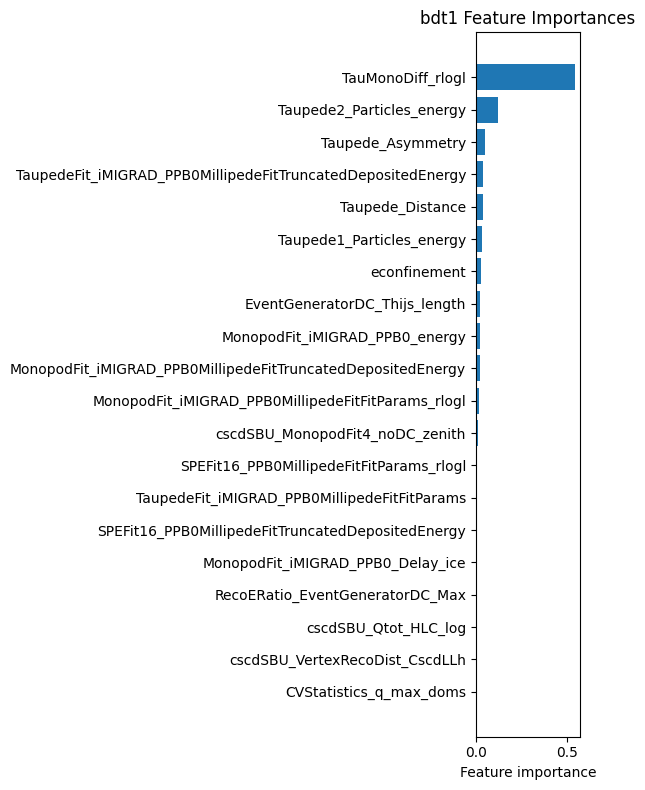

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_allfeatures/bdt1_importances.png
Fitting 5 folds for each of 96 candidates, totalling 480 fits
Saved best model to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_allfeatures/bdt2_model.pkl
Trained bdt2, saved to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_allfeatures/bdt2_model.pkl


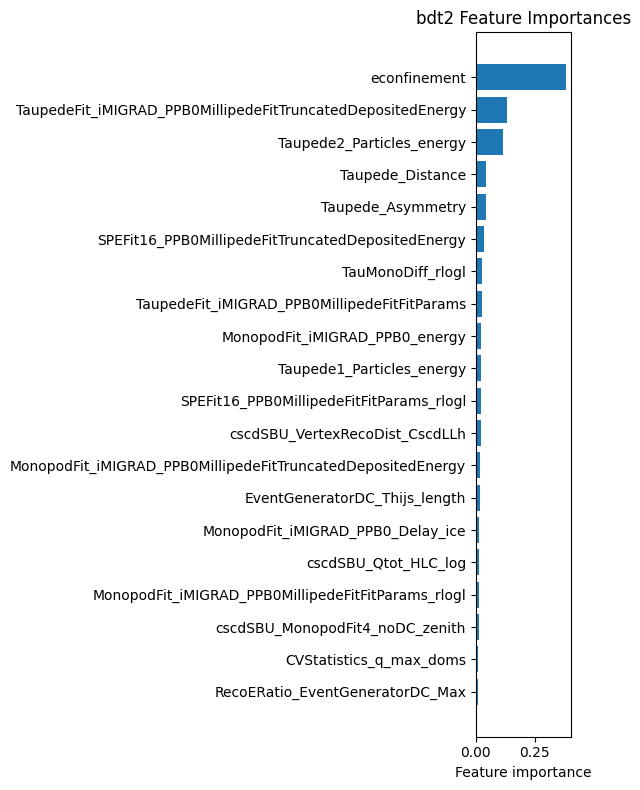

Saved feature importances to /data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_allfeatures/bdt2_importances.png

=== Pre-BDT rates ===
Calculating rates for flavor: nue
Raw event count: 34458
[weight] rate        = 4.7205e-08
[weight] uncertainty = 5.68053e-10
Calculating rates for flavor: numu
Raw event count: 42593
[weight] rate        = 2.74859e-08
[weight] uncertainty = 2.85702e-10
Calculating rates for flavor: nutau
Raw event count: 52638
[weight] rate        = 3.32846e-08
[weight] uncertainty = 4.17735e-10


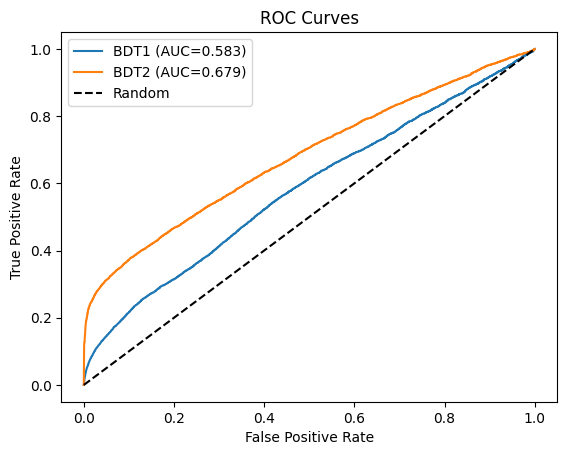

saving roc curves


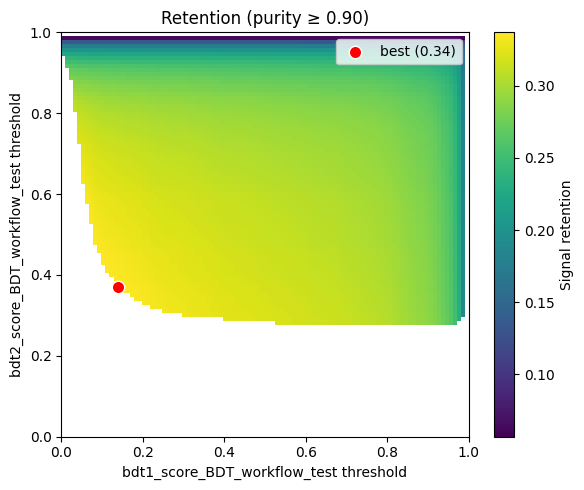


=== Post-BDT rates ===
Calculating post-BDT rates for flavor: nue
Raw event count: 811
[weight] rate        = 4.5747e-10
[weight] uncertainty = 3.97821e-11
Calculating post-BDT rates for flavor: numu
Raw event count: 4731
[weight] rate        = 7.7709e-10
[weight] uncertainty = 3.17369e-11
Calculating post-BDT rates for flavor: nutau
Raw event count: 34875
[weight] rate        = 1.12163e-08
[weight] uncertainty = 1.74043e-10


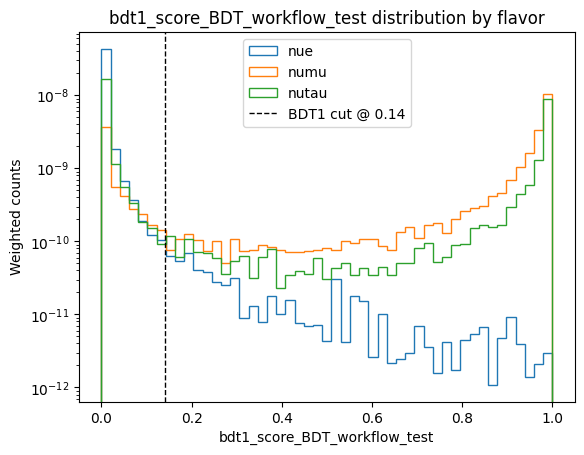

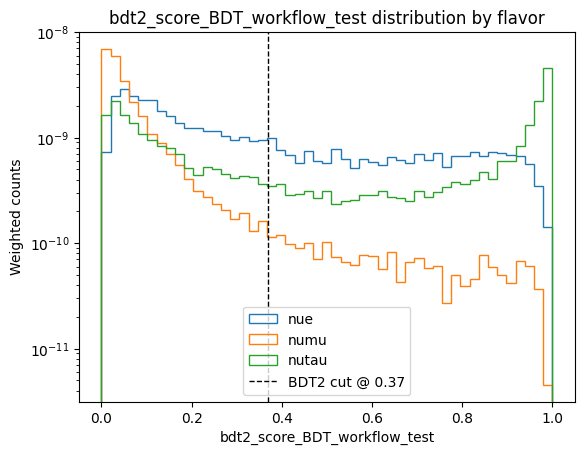

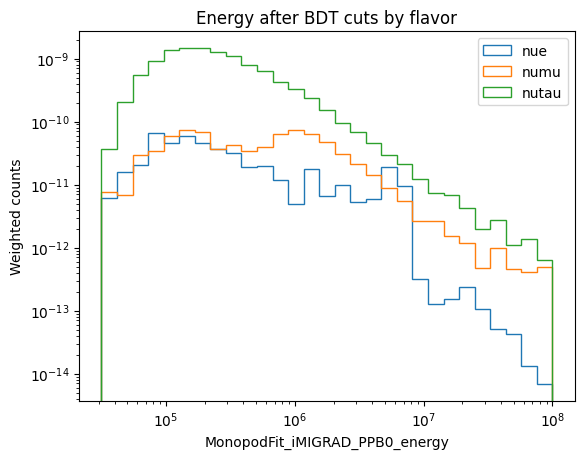


Final purity: 0.901, efficiency: 0.337


In [52]:
model_name = 'BDT_workflow_test'

models, summary = run_bdt_pipeline(
    df_train_precut, df_train_precut,
    global_precuts = None,
    model_configs  = model_configs,
    features       = features_list,
    weight_col     = 'weight',
    purity_target  = 0.90,
    score_cols     = [f'bdt1_score_{model_name}',f'bdt2_score_{model_name}'],
    train_outdir   = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/train_output_allfeatures/',
    eval_outdir    = '/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/eval_output_allfeatures/'
) 

compare roc

In [46]:
import matplotlib.pyplot as plt

# Read CSVs
def read_roc( inpath ):
    return pd.read_csv( inpath + "roc_curve1.csv" ), pd.read_csv( inpath + "roc_curve2.csv" )

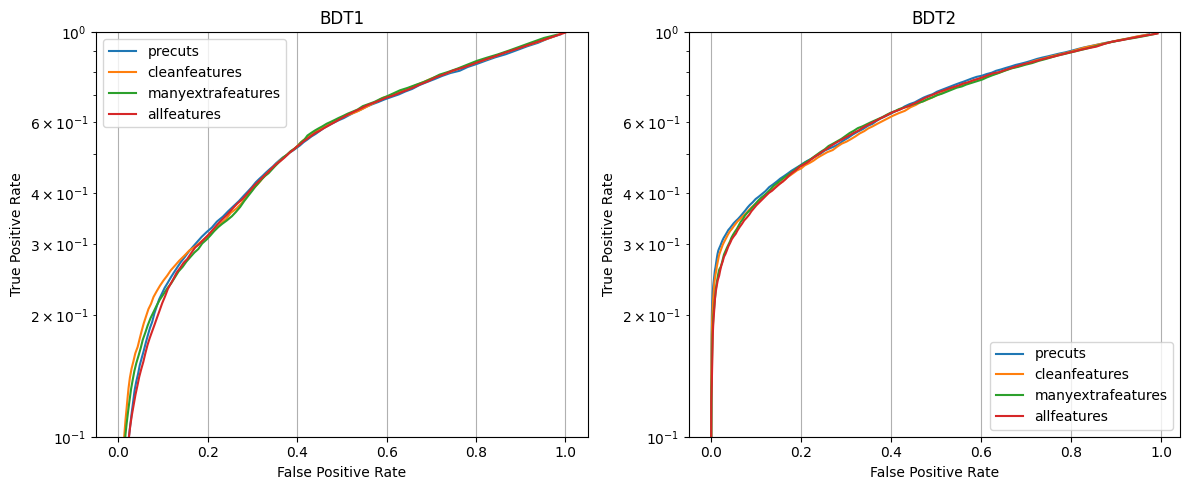

In [53]:
# Create side-by-side plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# plotting
for label in ["precuts", "cleanfeatures", "manyextrafeatures", "allfeatures"]:
    roc1, roc2 = read_roc( f"/data/user/tvaneede/GlobalFit/reco_processing/bdt/training/v0/eval_output_{label}/" )
    axes[0].plot(roc1['fpr'], roc1['tpr'], label=label)
    axes[1].plot(roc2['fpr'], roc2['tpr'], label=label)

axes[0].set_title('BDT1')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()
axes[0].grid(True)
axes[0].set_yscale("log")
axes[0].set_ylim(1e-1,1)


axes[1].set_title('BDT2')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True)
axes[1].set_yscale("log")
axes[1].set_ylim(1e-1,1)


plt.tight_layout()
plt.show()